# 02 · Build Dataset V3 Funcionarios / Miembros Riesgosos

Notebook para construir un dataset de **funcionarios/miembros vinculados a obras y empresas**, usando una etiqueta ordinal de 4 niveles.

## Objetivo
Construir un dataset más granular que permita modelar el nivel de riesgo de funcionarios o miembros vinculados a obras públicas.

## Archivos esperados
Ubicar los CSV en `data/external/funcionario/`:

- `DS_DASH_Miembro_1A.csv`
- `DS_DASH_Miembro_2A.csv`
- `DS_DASH_Miembro_3A.csv`
- `DS_DASH_Miembro_3B.csv`

## Unidad de análisis propuesta
Se generan dos datasets:

1. **Dataset funcionario único**: una fila por `CODIGO_DNI`.
2. **Dataset funcionario-obra/empresa**: una fila por vínculo entre funcionario, obra y/o empresa.

## Target ordinal de 4 niveles
Como no existe una columna explícita llamada `RIESGO_FUNCIONARIO`, se deriva una etiqueta preliminar desde señales de responsabilidad y sanción:

- `0`: Sin señales relevantes
- `1`: Bajo riesgo
- `2`: Medio riesgo
- `3`: Alto/Extremo riesgo

> Esta etiqueta es un proxy técnico para baseline. Debe validarse con expertos y documentación institucional.


In [9]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    candidates = [start, *start.parents]

    for c in candidates:
        has_readme = (c / "README.md").exists()
        has_src = (c / "src").exists()
        has_data_external = (c / "data" / "external").exists()
        has_pyproject = (c / "pyproject.toml").exists()
        has_requirements = (c / "requirements.txt").exists()

        if has_readme and has_data_external and (has_src or has_pyproject or has_requirements):
            return c

    raise FileNotFoundError(
        "No se pudo detectar la raíz del proyecto. "
        "Ejecuta el notebook desde el proyecto o ajusta PROJECT_ROOT manualmente."
    )


BASE = find_project_root()

DATA_EXT = BASE / "data" / "external" / "funcionario"
DATA_PROC = BASE / "data" / "processed"
REPORTS = BASE / "reports" / "figures"

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_EXT:", DATA_EXT)
print("DATA_PROC:", DATA_PROC)

BASE: c:\IA_Investigacion\Deteccion_Corrupcion
DATA_EXT: c:\IA_Investigacion\Deteccion_Corrupcion\data\external\funcionario
DATA_PROC: c:\IA_Investigacion\Deteccion_Corrupcion\data\processed


In [10]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.attrs["encoding"] = enc
            return df
        except Exception as exc:
            last_error = exc
    raise last_error


def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = (
        out.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.upper()
    )
    return out


def normalize_key(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .str.replace(".0", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )


FILES = {
    "m1a": "DS_DASH_Miembro_1A.csv",
    "m2a": "DS_DASH_Miembro_2A.csv",
    "m3a": "DS_DASH_Miembro_3A.csv",
    "m3b": "DS_DASH_Miembro_3B.csv",
}

tablas = {}

for key, fname in FILES.items():
    path = DATA_EXT / fname
    if not path.exists():
        alt = Path("/mnt/data") / fname
        path = alt if alt.exists() else path
    df = normalize_cols(read_csv_robust(path))
    tablas[key] = df
    print(f"{key}: {fname} -> shape={df.shape}, encoding={df.attrs.get('encoding')}")
    print("Columnas:", list(df.columns))
    print()


m1a: DS_DASH_Miembro_1A.csv -> shape=(1613, 10), encoding=latin1
Columnas: ['CODIGO_OBRA', 'CODIGO_DNI', 'TIPO_DOCUMENTO', 'NOMBRE_COMPLETO', 'RESP_PENAL', 'RESP_ADMIN', 'RESP_CIVIL', 'SANCIONADA_SERVIR', 'SANCIONADA_RNP', 'INHABILITADOS_SERVIR']

m2a: DS_DASH_Miembro_2A.csv -> shape=(739, 8), encoding=latin1
Columnas: ['CODIGO_DNI', 'TIPO_DOCUMENTO', 'NOMBRE_COMPLETO', 'RESP_PENAL', 'RESP_ADMIN', 'RESP_CIVIL', 'SANCIONADA_SERVIR', 'SANCIONADA_RNP']

m3a: DS_DASH_Miembro_3A.csv -> shape=(2606, 4), encoding=latin1
Columnas: ['CODIGO_RUC', 'NOMBRE_EMPRESA', 'CODIGO_DNI', 'NOMBRE_MIEMBRO']

m3b: DS_DASH_Miembro_3B.csv -> shape=(643, 4), encoding=latin1
Columnas: ['RUC_EMPRESA', 'NOMBRE_EMPRESA', 'DNI_REPRESENTANTE', 'NOMBRE_REPRESENTANTE']



In [11]:
perfil = []

for key, df in tablas.items():
    row = {
        "tabla": key,
        "filas": len(df),
        "columnas": len(df.columns),
    }
    for col in ["CODIGO_DNI", "DNI_REPRESENTANTE", "CODIGO_OBRA", "CODIGO_RUC", "RUC_EMPRESA"]:
        if col in df.columns:
            row[f"{col}_unicos"] = df[col].nunique(dropna=True)
    perfil.append(row)

perfil_df = pd.DataFrame(perfil)
perfil_df


,tabla,filas,columnas,CODIGO_DNI_unicos,CODIGO_OBRA_unicos,CODIGO_RUC_unicos,DNI_REPRESENTANTE_unicos,RUC_EMPRESA_unicos
0,m1a,1613,10,739.0,178.0,NaN,NaN,NaN
1,m2a,739,8,739.0,NaN,NaN,NaN,NaN
2,m3a,2606,4,737.0,NaN,313.0,NaN,NaN
3,m3b,643,4,NaN,NaN,NaN,629.0,240.0


## 1. Normalización de claves

Se estandarizan DNI, RUC y código de obra como texto para evitar errores de join.

In [12]:
for key, df in tablas.items():
    for col in ["CODIGO_DNI", "DNI_REPRESENTANTE", "CODIGO_OBRA", "CODIGO_RUC", "RUC_EMPRESA"]:
        if col in df.columns:
            df[col] = normalize_key(df[col])
    tablas[key] = df


## 2. Construcción de señales de riesgo

Se usan variables observables:

- `RESP_PENAL`
- `RESP_ADMIN`
- `RESP_CIVIL`
- `SANCIONADA_SERVIR`
- `SANCIONADA_RNP`
- `INHABILITADOS_SERVIR`

Se crea un puntaje simple. Esta regla es transparente para baseline, no reemplaza validación experta.

In [13]:
m1a = tablas["m1a"].copy()
m2a = tablas["m2a"].copy()

signal_cols = [
    "RESP_PENAL",
    "RESP_ADMIN",
    "RESP_CIVIL",
    "SANCIONADA_SERVIR",
    "SANCIONADA_RNP",
    "INHABILITADOS_SERVIR",
]

for df in [m1a, m2a]:
    for col in signal_cols:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Dataset base a nivel funcionario único desde m2a
func_base = m2a.drop_duplicates("CODIGO_DNI").copy()

func_base["score_responsabilidad"] = (
    func_base["RESP_PENAL"] * 3
    + func_base["RESP_ADMIN"] * 2
    + func_base["RESP_CIVIL"] * 2
)

func_base["score_sancion"] = (
    (func_base["SANCIONADA_SERVIR"] > 0).astype(int) * 3
    + (func_base["SANCIONADA_RNP"] > 0).astype(int) * 3
    + (func_base["INHABILITADOS_SERVIR"] > 0).astype(int) * 4
)

func_base["score_riesgo_funcionario"] = func_base["score_responsabilidad"] + func_base["score_sancion"]

def riesgo_4niveles(score):
    if score <= 0:
        return 0
    if score <= 2:
        return 1
    if score <= 6:
        return 2
    return 3

func_base["y_riesgo_funcionario_4niveles"] = func_base["score_riesgo_funcionario"].apply(riesgo_4niveles).astype(int)

print("Funcionarios únicos:", func_base["CODIGO_DNI"].nunique())
print(func_base["y_riesgo_funcionario_4niveles"].value_counts().sort_index())
func_base.head()


Funcionarios únicos: 739
y_riesgo_funcionario_4niveles
0    592
1      8
2     33
3    106
Name: count, dtype: int64


,CODIGO_DNI,TIPO_DOCUMENTO,NOMBRE_COMPLETO,RESP_PENAL,RESP_ADMIN,RESP_CIVIL,SANCIONADA_SERVIR,SANCIONADA_RNP,INHABILITADOS_SERVIR,score_responsabilidad,score_sancion,score_riesgo_funcionario,y_riesgo_funcionario_4niveles
0,10000679,DNI,GIANMARCO ANTONIO ANGULO CAIRO,0,0,0,0,0,0,0,0,0,0
1,10040819,DNI,RENE ALEJANDRO MONTALVO FLORES,0,0,0,0,0,0,0,0,0,0
2,10062144,DNI,LUZ ESMERALDA CORONEL CHAMORRO,0,0,0,0,0,0,0,0,0,0
3,10066521,DNI,ALFREDO ADALBERTO MORENO PISCONTE,0,0,0,0,0,0,0,0,0,0
4,10110638,DNI,RAUL SEVERINO CANCHO,0,0,0,0,0,0,0,0,0,0


## 3. Dataset granular funcionario-obra

`DS_DASH_Miembro_1A` contiene vínculos entre obra y funcionario. Se enriquece con la etiqueta calculada a nivel funcionario.

In [14]:
func_obra = m1a.copy()

# Agregados de presencia por funcionario
agg_func_obra = func_obra.groupby("CODIGO_DNI").agg(
    n_obras_vinculadas=("CODIGO_OBRA", "nunique"),
    n_registros_obra=("CODIGO_OBRA", "count"),
).reset_index()

func_base2 = func_base.merge(agg_func_obra, on="CODIGO_DNI", how="left")
func_base2[["n_obras_vinculadas", "n_registros_obra"]] = func_base2[["n_obras_vinculadas", "n_registros_obra"]].fillna(0)

func_obra_dataset = func_obra.merge(
    func_base2[[
        "CODIGO_DNI",
        "score_responsabilidad",
        "score_sancion",
        "score_riesgo_funcionario",
        "y_riesgo_funcionario_4niveles",
        "n_obras_vinculadas",
        "n_registros_obra",
    ]],
    on="CODIGO_DNI",
    how="left"
)

print("Dataset funcionario-obra:", func_obra_dataset.shape)
print("DNI únicos:", func_obra_dataset["CODIGO_DNI"].nunique())
print("Obras únicas:", func_obra_dataset["CODIGO_OBRA"].nunique())
print(func_obra_dataset["y_riesgo_funcionario_4niveles"].value_counts().sort_index())
func_obra_dataset.head()


Dataset funcionario-obra: (1613, 16)
DNI únicos: 739
Obras únicas: 178
y_riesgo_funcionario_4niveles
0    1325
1      16
2      61
3     211
Name: count, dtype: int64


,CODIGO_OBRA,CODIGO_DNI,TIPO_DOCUMENTO,NOMBRE_COMPLETO,RESP_PENAL,RESP_ADMIN,RESP_CIVIL,SANCIONADA_SERVIR,SANCIONADA_RNP,INHABILITADOS_SERVIR,score_responsabilidad,score_sancion,score_riesgo_funcionario,y_riesgo_funcionario_4niveles,n_obras_vinculadas,n_registros_obra
0,19777,21461664,DNI,LUZ YOLANDA ESQUIVEL CERON,0,0,0,0,0,0,0,0,0,0,2,2
1,19777,32977736,DNI,Hugo Antonio Cotos Perez,0,4,4,0,0,0,16,0,16,3,2,2
2,19777,41798624,DNI,FREDDY MANCHA CASO,0,2,0,0,0,0,4,0,4,2,2,2
3,19777,43584310,DNI,MARIA CECILIA PIÑAN INDACOCHEA,0,0,0,0,0,0,0,0,0,0,6,6
4,19777,9382177,DNI,ELKA CAROLINA ROSALES LAURENTE,0,1,2,0,0,0,6,0,6,2,3,3


## 4. Dataset granular funcionario-empresa

Se integran relaciones desde `DS_DASH_Miembro_3A` y `DS_DASH_Miembro_3B`.

- `3A`: empresa - miembro
- `3B`: empresa - representante


In [15]:
m3a = tablas["m3a"].copy()
m3b = tablas["m3b"].copy()

m3a = m3a.rename(columns={
    "CODIGO_RUC": "RUC_EMPRESA",
    "CODIGO_DNI": "CODIGO_DNI",
    "NOMBRE_MIEMBRO": "NOMBRE_FUNCIONARIO",
})

m3b = m3b.rename(columns={
    "DNI_REPRESENTANTE": "CODIGO_DNI",
    "NOMBRE_REPRESENTANTE": "NOMBRE_FUNCIONARIO",
})

m3a["tipo_vinculo_empresa"] = "MIEMBRO"
m3b["tipo_vinculo_empresa"] = "REPRESENTANTE"

cols_empresa = ["RUC_EMPRESA", "NOMBRE_EMPRESA", "CODIGO_DNI", "NOMBRE_FUNCIONARIO", "tipo_vinculo_empresa"]
func_empresa = pd.concat([
    m3a[cols_empresa],
    m3b[cols_empresa],
], ignore_index=True)

agg_func_empresa = func_empresa.groupby("CODIGO_DNI").agg(
    n_empresas_vinculadas=("RUC_EMPRESA", "nunique"),
    n_registros_empresa=("RUC_EMPRESA", "count"),
    n_tipos_vinculo_empresa=("tipo_vinculo_empresa", "nunique"),
).reset_index()

func_empresa_dataset = func_empresa.merge(
    func_base2[[
        "CODIGO_DNI",
        "score_responsabilidad",
        "score_sancion",
        "score_riesgo_funcionario",
        "y_riesgo_funcionario_4niveles",
        "n_obras_vinculadas",
        "n_registros_obra",
    ]],
    on="CODIGO_DNI",
    how="left"
).merge(
    agg_func_empresa,
    on="CODIGO_DNI",
    how="left"
)

print("Dataset funcionario-empresa:", func_empresa_dataset.shape)
print("DNI únicos:", func_empresa_dataset["CODIGO_DNI"].nunique())
print("Empresas únicas:", func_empresa_dataset["RUC_EMPRESA"].nunique())
print(func_empresa_dataset["y_riesgo_funcionario_4niveles"].value_counts(dropna=False).sort_index())
func_empresa_dataset.head()


Dataset funcionario-empresa: (3249, 14)
DNI únicos: 1366
Empresas únicas: 351
y_riesgo_funcionario_4niveles
0.0    2174
1.0      24
2.0      88
3.0     320
NaN     643
Name: count, dtype: int64


,RUC_EMPRESA,NOMBRE_EMPRESA,CODIGO_DNI,NOMBRE_FUNCIONARIO,tipo_vinculo_empresa,score_responsabilidad,score_sancion,score_riesgo_funcionario,y_riesgo_funcionario_4niveles,n_obras_vinculadas,n_registros_obra,n_empresas_vinculadas,n_registros_empresa,n_tipos_vinculo_empresa
0,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,40475086,ASENCION EZEQUIEL RIOS GALLARDO,MIEMBRO,0.0,0.0,0.0,0.0,1.0,2.0,7,7,1
1,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,44243793,MARIO ESLY WU VEGA,MIEMBRO,0.0,0.0,0.0,0.0,1.0,2.0,7,7,1
2,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,5339039,SEGUNDO GERMAN RIOS VASQUEZ,MIEMBRO,0.0,0.0,0.0,0.0,1.0,2.0,7,7,1
3,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,5402152,ABDY RODRIGUEZ MONTALVAN,MIEMBRO,0.0,0.0,0.0,0.0,1.0,2.0,7,7,1
4,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,5403466,MARIO RENE GONZALES MOREY,MIEMBRO,0.0,0.0,0.0,0.0,1.0,2.0,7,7,1


## 5. Dataset integrado funcionario-vínculo

Se unifican los vínculos obra y empresa para aumentar granularidad. Para baseline, este dataset tiene más registros, pero debe usarse split por grupos (`CODIGO_DNI`) para evitar leakage.

In [16]:
# Preparar obra
fo = func_obra_dataset.copy()
fo["tipo_vinculo"] = "OBRA"
fo["RUC_EMPRESA"] = np.nan
fo["NOMBRE_EMPRESA"] = np.nan
fo["tipo_vinculo_empresa"] = np.nan

# Preparar empresa
fe = func_empresa_dataset.copy()
fe["tipo_vinculo"] = "EMPRESA"
fe["CODIGO_OBRA"] = np.nan
for col in ["TIPO_DOCUMENTO", "NOMBRE_COMPLETO", "RESP_PENAL", "RESP_ADMIN", "RESP_CIVIL", "SANCIONADA_SERVIR", "SANCIONADA_RNP", "INHABILITADOS_SERVIR"]:
    if col not in fe.columns:
        fe[col] = np.nan

common_cols = sorted(set(fo.columns).intersection(set(fe.columns)))
func_vinculo = pd.concat([fo[common_cols], fe[common_cols]], ignore_index=True)

# Completar agregados de empresa a todos
func_vinculo = func_vinculo.merge(agg_func_empresa, on="CODIGO_DNI", how="left", suffixes=("", "_agg"))
for col in ["n_empresas_vinculadas", "n_registros_empresa", "n_tipos_vinculo_empresa"]:
    alt = col + "_agg"
    if alt in func_vinculo.columns:
        func_vinculo[col] = func_vinculo[col].fillna(func_vinculo[alt])
        func_vinculo = func_vinculo.drop(columns=[alt])
    func_vinculo[col] = func_vinculo[col].fillna(0)

print("Dataset integrado:", func_vinculo.shape)
print("DNI únicos:", func_vinculo["CODIGO_DNI"].nunique())
print(func_vinculo["y_riesgo_funcionario_4niveles"].value_counts(dropna=False).sort_index())
func_vinculo.head()


Dataset integrado: (4862, 23)
DNI únicos: 1368
y_riesgo_funcionario_4niveles
0.0    3499
1.0      40
2.0     149
3.0     531
NaN     643
Name: count, dtype: int64


,CODIGO_DNI,CODIGO_OBRA,INHABILITADOS_SERVIR,NOMBRE_COMPLETO,NOMBRE_EMPRESA,RESP_ADMIN,RESP_CIVIL,RESP_PENAL,RUC_EMPRESA,SANCIONADA_RNP,...,n_registros_obra,score_responsabilidad,score_riesgo_funcionario,score_sancion,tipo_vinculo,tipo_vinculo_empresa,y_riesgo_funcionario_4niveles,n_empresas_vinculadas,n_registros_empresa,n_tipos_vinculo_empresa
0,21461664,19777,0.0,LUZ YOLANDA ESQUIVEL CERON,NaN,0.0,0.0,0.0,NaN,0.0,...,2.0,0.0,0.0,0.0,OBRA,NaN,0.0,2.0,2.0,1.0
1,32977736,19777,0.0,Hugo Antonio Cotos Perez,NaN,4.0,4.0,0.0,NaN,0.0,...,2.0,16.0,16.0,0.0,OBRA,NaN,3.0,2.0,2.0,1.0
2,41798624,19777,0.0,FREDDY MANCHA CASO,NaN,2.0,0.0,0.0,NaN,0.0,...,2.0,4.0,4.0,0.0,OBRA,NaN,2.0,2.0,2.0,1.0
3,43584310,19777,0.0,MARIA CECILIA PIÑAN INDACOCHEA,NaN,0.0,0.0,0.0,NaN,0.0,...,6.0,0.0,0.0,0.0,OBRA,NaN,0.0,11.0,11.0,1.0
4,9382177,19777,0.0,ELKA CAROLINA ROSALES LAURENTE,NaN,1.0,2.0,0.0,NaN,0.0,...,3.0,6.0,6.0,0.0,OBRA,NaN,2.0,2.0,2.0,1.0


## 6. EDA de target y señales

,n
y_riesgo_funcionario_4niveles,
0.0,3499
1.0,40
2.0,149
3.0,531
NaN,643


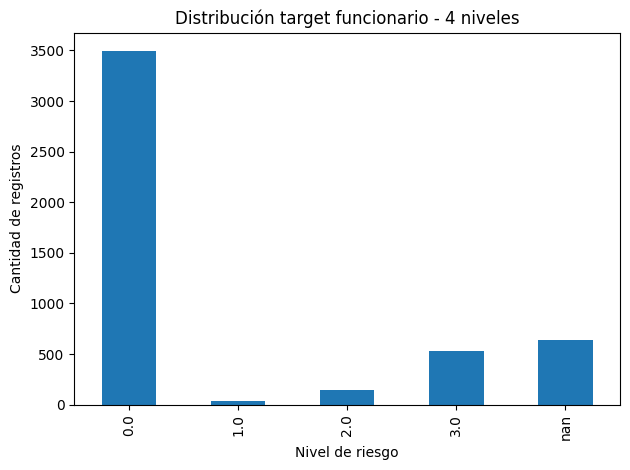

,score_responsabilidad,score_sancion,score_riesgo_funcionario,n_obras_vinculadas,n_empresas_vinculadas
count,4219.000000,4219.000000,4219.000000,4219.000000,4862.000000
mean,2.693292,0.104527,2.797819,3.192937,6.073838
std,8.483872,0.550207,8.657140,2.982601,6.063344
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,2.000000
50%,0.000000,0.000000,0.000000,2.000000,4.000000
75%,0.000000,0.000000,0.000000,4.000000,8.000000
max,96.000000,3.000000,99.000000,14.000000,29.000000


In [17]:
target_col = "y_riesgo_funcionario_4niveles"

dist = func_vinculo[target_col].value_counts(dropna=False).sort_index()
display(dist.to_frame("n"))

if plt is not None:
    ax = dist.plot(kind="bar", title="Distribución target funcionario - 4 niveles")
    ax.set_xlabel("Nivel de riesgo")
    ax.set_ylabel("Cantidad de registros")
    plt.tight_layout()
    plt.show()

cols_score = ["score_responsabilidad", "score_sancion", "score_riesgo_funcionario", "n_obras_vinculadas", "n_empresas_vinculadas"]
display(func_vinculo[cols_score].describe())


## 7. Control de leakage y limpieza

No se entrenará con columnas que definen directamente el target:

- responsabilidades
- sanciones
- scores derivados
- nombre del funcionario

Para un baseline honesto, se dejan variables de vínculo y agregados, pero no las columnas usadas para construir la etiqueta.

In [18]:
LEAKAGE_COLS = [
    "RESP_PENAL",
    "RESP_ADMIN",
    "RESP_CIVIL",
    "SANCIONADA_SERVIR",
    "SANCIONADA_RNP",
    "INHABILITADOS_SERVIR",
    "score_responsabilidad",
    "score_sancion",
    "score_riesgo_funcionario",
]

ID_COLS = [
    "CODIGO_DNI",
    "NOMBRE_COMPLETO",
    "NOMBRE_FUNCIONARIO",
]

model_df = func_vinculo.dropna(subset=[target_col]).copy()
model_df[target_col] = model_df[target_col].astype(int)

drop_for_x = LEAKAGE_COLS + [target_col]
X = model_df.drop(columns=drop_for_x, errors="ignore")
y = model_df[target_col]
groups = model_df["CODIGO_DNI"]

# eliminar columnas completamente nulas y constantes
all_nan = [c for c in X.columns if X[c].isna().all()]
const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]

X_clean = X.drop(columns=all_nan + const_cols, errors="ignore")

print("Filas modelo:", len(X_clean))
print("Columnas iniciales X:", X.shape[1])
print("Columnas removidas 100% nulas:", all_nan)
print("Columnas constantes:", const_cols)
print("Columnas finales X:", X_clean.shape[1])
print("Distribución y:")
print(y.value_counts().sort_index())


Filas modelo: 4219
Columnas iniciales X: 13
Columnas removidas 100% nulas: []
Columnas constantes: ['TIPO_DOCUMENTO', 'tipo_vinculo_empresa']
Columnas finales X: 11
Distribución y:
y_riesgo_funcionario_4niveles
0    3499
1      40
2     149
3     531
Name: count, dtype: int64


## 8. Baseline multiclase con split por grupos

Se usa `GroupShuffleSplit` agrupando por `CODIGO_DNI` para evitar que el mismo funcionario aparezca en entrenamiento y prueba.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

num_cols = X_clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_clean, y, groups=groups))

X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

clf = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_groups_train": int(groups.iloc[train_idx].nunique()),
    "n_groups_test": int(groups.iloc[test_idx].nunique()),
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


{
  "accuracy": 0.7992874109263658,
  "balanced_accuracy": 0.35926441582550184,
  "macro_f1": 0.3511483082781326,
  "weighted_f1": 0.7401277823247797,
  "n_train": 3377,
  "n_test": 842,
  "n_groups_train": 591,
  "n_groups_test": 148
}

Classification report:
              precision    recall  f1-score   support

           0     0.8166    0.9749    0.8887       676
           2     0.0000    0.0000    0.0000        30
           3     0.4118    0.1029    0.1647       136

    accuracy                         0.7993       842
   macro avg     0.4095    0.3593    0.3511       842
weighted avg     0.7221    0.7993    0.7401       842


Matriz de confusión:
[[659   0  17]
 [ 27   0   3]
 [121   1  14]]


## 9. Guardado de datasets, metadata y métricas

In [20]:
out_func = DATA_PROC / "dataset_funcionario_v3_4niveles_unico.parquet"
out_obra = DATA_PROC / "dataset_funcionario_v3_4niveles_obra.parquet"
out_empresa = DATA_PROC / "dataset_funcionario_v3_4niveles_empresa.parquet"
out_vinculo = DATA_PROC / "dataset_funcionario_v3_4niveles_vinculo.parquet"
out_model = DATA_PROC / "dataset_funcionario_v3_4niveles_model.parquet"

func_base2.to_parquet(out_func, index=False)
func_obra_dataset.to_parquet(out_obra, index=False)
func_empresa_dataset.to_parquet(out_empresa, index=False)
func_vinculo.to_parquet(out_vinculo, index=False)

model_out = X_clean.copy()
model_out[target_col] = y.values
model_out["CODIGO_DNI_GROUP"] = groups.values
model_out.to_parquet(out_model, index=False)

meta = {
    "unidad_funcionario": "CODIGO_DNI",
    "target": target_col,
    "target_definicion": {
        "0": "sin señales",
        "1": "bajo riesgo",
        "2": "medio riesgo",
        "3": "alto/extremo riesgo",
    },
    "regla_score": {
        "score_responsabilidad": "RESP_PENAL*3 + RESP_ADMIN*2 + RESP_CIVIL*2",
        "score_sancion": "SERVIR>0*3 + RNP>0*3 + INHABILITADO>0*4",
        "clases": "0 si score<=0; 1 si <=2; 2 si <=6; 3 si >6",
    },
    "shapes": {
        "funcionario_unico": list(func_base2.shape),
        "funcionario_obra": list(func_obra_dataset.shape),
        "funcionario_empresa": list(func_empresa_dataset.shape),
        "funcionario_vinculo": list(func_vinculo.shape),
        "modelo": list(model_out.shape),
    },
    "distribucion_target_modelo": {str(k): int(v) for k, v in y.value_counts().sort_index().items()},
    "leakage_cols_excluidas": LEAKAGE_COLS,
    "metrics_baseline": metrics,
}

meta_path = DATA_PROC / "dataset_funcionario_v3_4niveles_meta.json"
metrics_path = DATA_PROC / "baseline_funcionario_4niveles_metrics.json"

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print("Guardado:")
for p in [out_func, out_obra, out_empresa, out_vinculo, out_model, meta_path, metrics_path]:
    print("-", p)


Guardado:
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_unico.parquet
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_obra.parquet
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_empresa.parquet
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_vinculo.parquet
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_model.parquet
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_meta.json
- c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\baseline_funcionario_4niveles_metrics.json


## 10. Conclusiones técnicas

- El dataset de funcionarios tiene una base de **739 funcionarios únicos** en `Miembro_2A`.
- `Miembro_1A` permite construir vínculos funcionario-obra.
- `Miembro_3A` y `Miembro_3B` permiten construir vínculos funcionario-empresa.
- La etiqueta de 4 niveles es un **proxy transparente**, derivado de responsabilidades y sanciones.
- Para evitar leakage, las columnas usadas para construir la etiqueta se excluyen del entrenamiento.
- El split por grupos evita que el mismo funcionario aparezca simultáneamente en train y test.
